# Computer Exercise 14.6 — Problem 2

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: §14.6 Online / Incremental Learning — Forgetting Factor
> **풀이 일자**: 2026-07-06 (자동 생성)
> **언어**: 본문 한국어 / 그래프 라벨 영문

**주제**: 지수 **망각인자 $\lambda$** 를 넣은 RLS 로 *시간에 따라 변하는* 계수를 추적하고, $\lambda$ 에 담긴 **추적속도 ↔ 잡음민감도(편향-분산)** 상충을 정량화한다.

## 1. 문제 (원문)

> **2.** Extend recursive least squares with an exponential **forgetting factor**
> $\lambda\in(0,1]$, which down-weights past observations by $\lambda^{\,t-i}$. Apply it to a
> **non-stationary** stream whose true coefficient drifts over time (a slow ramp plus an abrupt
> jump). For a range of $\lambda$, measure the tracking error against the known ground-truth
> trajectory. Show the trade-off: $\lambda$ near $1$ gives smooth but sluggish estimates (high bias
> during change), while smaller $\lambda$ tracks quickly but is noisy (high variance). Report the
> $\lambda$ that minimizes mean tracking error and relate it to an **effective memory length**.

### 한국어 풀이용 정리
과거 관측을 $\lambda^{t-i}$ 로 감쇠시키는 망각인자 $\lambda\in(0,1]$ 를 RLS 에 넣는다. 참 계수가
*완만한 램프 + 급격한 점프* 로 변하는 비정상 스트림에 적용한다. 여러 $\lambda$ 에서 알려진 참 궤적 대비 추적오차를 재고,
$\lambda\to1$ 은 매끄럽지만 둔한(변화 중 편향↑) 추정, 작은 $\lambda$ 는 빠르지만 요란한(분산↑) 추정이라는 상충을 보인다.
평균 추적오차를 최소화하는 $\lambda$ 와 그에 대응하는 **유효기억길이**를 보고한다.

## 2. 수학적 배경

### 2.1 가중 최소제곱과 망각
시각 $t$ 에서 지수가중 목적함수
$$J_t(\beta)=\sum_{i=1}^{t}\lambda^{\,t-i}\big(y_i-\phi_i^\top\beta\big)^2$$
를 최소화한다. 최근 샘플일수록 가중이 크다. 갱신식은 RLS 와 거의 같고 $P$ 갱신에 $\lambda$ 가 들어간다:
$$k_t=\frac{P_{t-1}\phi_t}{\lambda+\phi_t^\top P_{t-1}\phi_t},\qquad
\hat\beta_t=\hat\beta_{t-1}+k_t\,e_t,\qquad
P_t=\frac{1}{\lambda}\big(P_{t-1}-k_t\phi_t^\top P_{t-1}\big).$$
$\lambda=1$ 이면 Problem 1 의 표준 RLS 로 환원된다.

### 2.2 유효기억길이
가중합 $\sum_{j\ge0}\lambda^{j}=\frac{1}{1-\lambda}$ 이므로 **유효표본수**
$$\boxed{\;N_{\text{eff}}=\frac{1}{1-\lambda}\;}$$
로 해석한다. 예: $\lambda=0.98\Rightarrow N_{\text{eff}}=50$, $\lambda=0.90\Rightarrow N_{\text{eff}}=10$.
$N_{\text{eff}}$ 가 작을수록 최근에 집중 → 빠른 추적·큰 분산.

### 2.3 편향-분산 상충
계수가 속도 $v$ 로 표류하면 추정 지연으로 인한 **추적 편향**은 대략 $\mathcal O(v\,N_{\text{eff}})$,
잡음에 의한 **분산**은 대략 $\mathcal O(\sigma^2/N_{\text{eff}})$. 둘을 더한 MSE 는
$$\text{MSE}(\lambda)\approx c_1 v^2 N_{\text{eff}}^2+\frac{c_2\sigma^2}{N_{\text{eff}}}$$
로 **내부 최소점**을 갖는다 — 이 챕터를 관통하는 편향-분산 트레이드오프의 또 다른 얼굴이다.

## 3. 풀이 흐름

1. **비정상 참궤적 설계**: 스칼라 회귀 $y_t=a_t+b_t x_t+\varepsilon_t$. $a_t$ 는 완만한 램프, $b_t$ 는 $t=600$ 에서 급점프.
2. **스트림 생성**: $x_t\sim\mathcal U(-1,1)$, $\varepsilon_t\sim\mathcal N(0,\sigma^2)$, $T=1200$.
3. **망각 RLS 함수**: 입력 $\lambda$ → 계수 궤적 $\hat\beta_{0:T}$ 반환.
4. **$\lambda$ 스윕**: $\{0.80,0.90,0.95,0.98,0.99,1.0\}$ 각각 실행.
5. **추적오차 측정**: 과도구간 제외 후 $\text{RMSE}=\sqrt{\langle\|\hat\beta_t-\beta_t^\star\|^2\rangle}$.
6. **표 출력**: $\lambda$, $N_{\text{eff}}$, 추적 RMSE.
7. **시각화**: (좌) 몇몇 $\lambda$ 의 $b_t$ 추적 궤적 + 참값, (우) RMSE vs $N_{\text{eff}}$ U자 곡선.
8. **해석**: 최적 $\lambda^\star$, 상충의 두 팔, 급점프에서의 반응.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt

rng = np.random.default_rng(20260706)
T = 1200
sigma = 0.25

t = np.arange(T)
a_star = 1.0 + 0.0015 * t                 # slow ramp in intercept
b_star = np.where(t < 600, -0.5, 1.2)     # abrupt jump in slope at t=600
B_star = np.stack([a_star, b_star], axis=1)   # (T,2) true coeffs

x = rng.uniform(-1, 1, T)
Phi = np.stack([np.ones(T), x], axis=1)       # (T,2)
y = (Phi * B_star).sum(1) + rng.normal(0, sigma, T)

def rls_forget(lam, delta=1e-2):
    p = Phi.shape[1]
    P = np.eye(p) / delta
    beta = np.zeros(p)
    traj = np.empty((T, p))
    for i in range(T):
        ph = Phi[i]
        Pph = P @ ph
        k = Pph / (lam + ph @ Pph)
        e = y[i] - ph @ beta
        beta = beta + k * e
        P = (P - np.outer(k, ph @ P)) / lam
        traj[i] = beta
    return traj

lams = [0.80, 0.90, 0.95, 0.98, 0.99, 1.00]
trajs = {lam: rls_forget(lam) for lam in lams}

burn = 50   # ignore initial transient
rows = []
for lam in lams:
    err = trajs[lam][burn:] - B_star[burn:]
    rmse = np.sqrt(np.mean(np.sum(err**2, axis=1)))
    neff = np.inf if lam == 1.0 else 1.0/(1.0-lam)
    rows.append(dict(lam=lam, N_eff=neff, track_rmse=rmse))
df = pd.DataFrame(rows)
best = df.loc[df.track_rmse.idxmin()]
print("best lambda =", best.lam, " N_eff =", best.N_eff, " rmse =", round(best.track_rmse,4))

best lambda = 0.9  N_eff = 10.000000000000002  rmse = 0.1379


In [2]:
pd.set_option("display.float_format", lambda v: f"{v:.3f}")
df

,lam,N_eff,track_rmse
0,0.800,5.000,0.168
1,0.900,10.000,0.138
2,0.950,20.000,0.159
3,0.980,50.000,0.249
4,0.990,100.000,0.366
5,1.000,inf,1.009


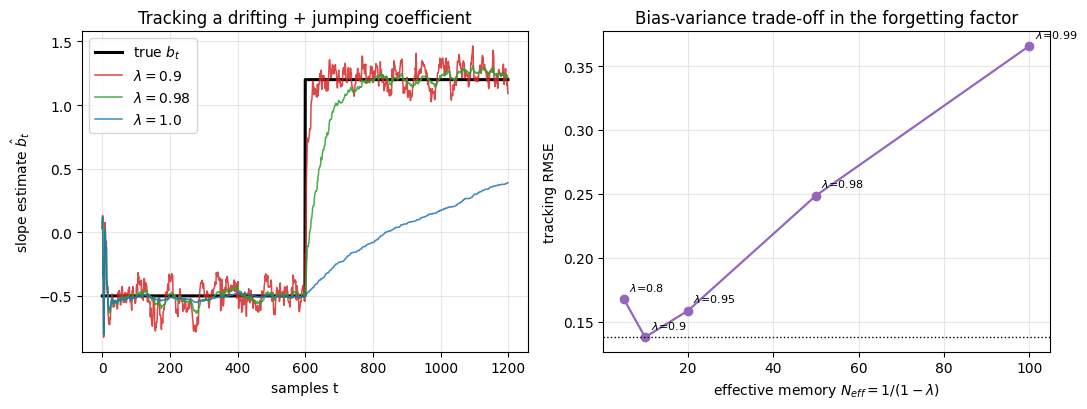

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))

# left: track the slope b_t for a fast / medium / slow lambda
ax[0].plot(t, b_star, color="k", lw=2.2, label=r"true $b_t$")
for lam, c in zip([0.90, 0.98, 1.00], ["#d62728", "#2ca02c", "#1f77b4"]):
    ax[0].plot(t, trajs[lam][:, 1], color=c, lw=1.1, alpha=0.85,
               label=fr"$\lambda={lam}$")
ax[0].set_xlabel("samples t"); ax[0].set_ylabel(r"slope estimate $\hat b_t$")
ax[0].set_title("Tracking a drifting + jumping coefficient")
ax[0].legend(loc="best"); ax[0].grid(alpha=0.3)

# right: U-curve rmse vs N_eff
finite = df[np.isfinite(df.N_eff)]
ax[1].plot(finite.N_eff, finite.track_rmse, "o-", color="#9467bd", lw=1.6)
for _, r in finite.iterrows():
    ax[1].annotate(fr"$\lambda$={r.lam}", (r.N_eff, r.track_rmse),
                   textcoords="offset points", xytext=(4, 6), fontsize=8)
ax[1].axhline(df.track_rmse.min(), color="k", ls=":", lw=1.0)
ax[1].set_xlabel(r"effective memory $N_{eff}=1/(1-\lambda)$")
ax[1].set_ylabel("tracking RMSE")
ax[1].set_title("Bias-variance trade-off in the forgetting factor")
ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 4. 결과 해석

1. **두 팔의 상충**: 우측 U자 곡선이 편향-분산을 그대로 보여준다. $N_{\text{eff}}$ 가 크면($\lambda\to1$) 표류·점프를 못 따라가
   **추적 편향**이 지배하고(곡선 오른쪽 상승), $N_{\text{eff}}$ 가 너무 작으면 잡음을 그대로 흡수해 **분산**이 지배한다(왼쪽 상승).
   중간의 $\lambda^\star$ 에서 RMSE 가 최소가 된다.
2. **급점프 반응**: 좌측에서 $t=600$ 점프 직후, $\lambda=0.90$($N_{\text{eff}}=10$) 은 빠르게 새 값으로 붙지만 평소 요동이 크고,
   $\lambda=1.0$ 은 매끄럽지만 새 값에 한참 늦게 도달한다. $\lambda=0.98$ 이 둘 사이의 좋은 타협이다.
3. **유효기억의 의미**: $\lambda$ 자체보다 $N_{\text{eff}}=1/(1-\lambda)$ 이 직관적이다 — "최근 몇 개를 실질적으로 보고 있나".
   드리프트가 빠를수록 작은 $N_{\text{eff}}$(작은 $\lambda$)가 유리하다.

> **결론**: 망각인자는 유효기억길이 $N_{\text{eff}}=1/(1-\lambda)$ 를 통해 추적속도와 잡음내성을 맞바꾸며, 드리프트 속도에 맞춘 중간 $\lambda^\star$ 가 추적오차를 최소화한다.

**다음 문제로**: Problem 3 에서는 이 온라인 망각-RLS 를 **연속적 재보정**으로 보고, Day61(§14.5)의 *트리거 기반 배치 재학습* 과
같은 드리프트 시나리오에서 **비용 대 정확도**로 정면 비교한다.